## 1. Notebook purpose

This notebook performs exploratory data analysis and modeling-readiness checks on the curated Gold source table:

`gold.gold_m5_daily_feature_mart`

Its purpose is to confirm that the dataset is suitable for forecasting model development before any feature engineering or model training begins.

This notebook will specifically verify:

- the table can be accessed from the warehouse successfully
- the dataset shape and schema are consistent with expectations
- the grain is truly one row per `(store_id, item_id, date)`
- the target variable `sales` is present and sensible
- missingness, sparsity, and obvious quality issues are understood
- feature families are reviewed before modeling decisions are made
- possible leakage-risk columns are identified early

This notebook is intentionally limited to **EDA and data quality for modeling**.

It does **not** perform:

- model training
- lag or rolling feature engineering
- MLflow experiment tracking
- model registration
- batch inference logic
- retraining workflow design

This keeps the notebook focused, readable, and production-aligned so that later notebook and Python training code can build on a clear and stable foundation.

# Load libraries and configure display

In [1]:
# Core
import warnings

# Data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 200)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
from sqlalchemy import text

from app_config.config import settings
from database.database import warehouse_engine

print("Settings and warehouse engine imported successfully.")
print("Configured warehouse DSN present:", bool(settings.WAREHOUSE_DSN or settings.POSTGRES_DSN))

Settings and warehouse engine imported successfully.
Configured warehouse DSN present: True


## Load data from gold.gold_m5_daily_feature_mart

In [3]:
sample_query = """
select *
from gold.gold_m5_daily_feature_mart
limit 10
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(sample_query))
    sample_df = pd.DataFrame(result.fetchall(), columns=result.keys())

sample_df

,id,item_id,dept_id,cat_id,store_id,state_id,d,date,wm_yr_wk,sales,sell_price,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,cpi_all_items,unemployment_rate,federal_funds_rate,nonfarm_payrolls,trends_walmart,trends_grocery_store,trends_discount_store,trends_cleaning_supplies
0,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_2,2011-01-30,11101,0,2,11.1,5.3,9.4,10.9,221,9,0,130837,83,65,66,73
1,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_207,2011-08-23,11130,1,1,36.6,19.3,0.0,8.0,226,9,0,132125,17,23,51,71
2,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_258,2011-10-13,11137,0,1,29.5,14.0,0.0,8.2,226,8,0,132553,16,25,44,67
3,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_463,2012-05-05,11215,1,2,23.4,8.8,0.0,10.7,228,8,0,133932,77,81,75,54
4,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_514,2012-06-25,11222,0,2,27.5,15.2,0.0,14.9,228,8,0,134013,74,72,76,64
5,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_719,2013-01-16,11251,0,2,12.7,0.6,0.0,6.8,231,8,0,135257,17,23,41,66
6,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_770,2013-03-08,11306,0,2,10.3,4.8,2.9,9.3,232,7,0,135689,64,51,73,62
7,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_975,2013-09-29,11336,0,2,30.8,12.1,0.0,14.7,233,7,0,136821,24,26,53,67
8,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_1026,2013-11-19,11343,0,2,18.1,10.3,0.0,11.6,234,6,0,137317,29,20,53,80
9,HOBBIES_2_120_CA_4_validation,HOBBIES_2_120,HOBBIES_2,HOBBIES,CA_4,CA,d_1231,2014-06-12,11419,0,2,34.7,20.7,0.0,13.6,237,6,0,138849,71,54,72,74


In [4]:
print("Sample shape:", sample_df.shape)
print()
print("Columns:")
print(sample_df.columns.tolist())
print()
print("Dtypes:")
print(sample_df.dtypes)

Sample shape: (10, 23)

Columns:
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'date', 'wm_yr_wk', 'sales', 'sell_price', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum', 'wind_speed_10m_max', 'cpi_all_items', 'unemployment_rate', 'federal_funds_rate', 'nonfarm_payrolls', 'trends_walmart', 'trends_grocery_store', 'trends_discount_store', 'trends_cleaning_supplies']

Dtypes:
id                           object
item_id                      object
dept_id                      object
cat_id                       object
store_id                     object
state_id                     object
d                            object
date                         object
wm_yr_wk                      int64
sales                         int64
sell_price                   object
temperature_2m_max          float64
temperature_2m_min          float64
precipitation_sum           float64
wind_speed_10m_max          float64
cpi_all_items                object
unemploym

## Confirm dataset shape and schema


The sample query confirms that the table can be accessed successfully from the warehouse.

The dataset includes identifiers, time columns, the target variable (`sales`), price information, weather features, macroeconomic indicators, and Google Trends signals.

However, since only a small sample was loaded, the dtype information from pandas should not yet be treated as authoritative. The next step is to profile the full table at the warehouse level to understand:

- total row count
- date coverage
- number of unique items and stores

This allows us to confirm that the dataset structure matches the expected forecasting grain.

In [5]:
profile_query = """
select
    count(*) as row_count,
    count(distinct store_id) as n_store_id,
    count(distinct item_id) as n_item_id,
    count(distinct state_id) as n_state_id,
    min(date) as min_date,
    max(date) as max_date
from gold.gold_m5_daily_feature_mart
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(profile_query))
    profile_df = pd.DataFrame(result.fetchall(), columns=result.keys())

profile_df

,row_count,n_store_id,n_item_id,n_state_id,min_date,max_date
0,58327370,10,3049,3,2011-01-29,2016-04-24


# ### Warehouse profile summary

The warehouse-level profile confirms the structure of the dataset:

- total rows: **58327370**
- unique stores: **10**
- unique items: **3,049**
- unique states: **3**
- date range: **2011-01-29 → 2016-04-24**

This confirms that the dataset represents a multi-store, multi-item daily sales dataset suitable for forecasting.

The row count also indicates that the dataset is large enough to justify warehouse-side aggregation and profiling rather than loading the full dataset into pandas during EDA.

## 5. Check date coverage and forecasting grain

In [6]:
grain_check_query = """
select
    count(*) as total_rows,
    count(distinct store_id || '_' || item_id || '_' || date) as distinct_store_item_date_rows
from gold.gold_m5_daily_feature_mart
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(grain_check_query))
    grain_df = pd.DataFrame(result.fetchall(), columns=result.keys())

grain_df

,total_rows,distinct_store_item_date_rows
0,58327370,58327370


### Grain validation result

The grain check confirms that the dataset follows the expected structure.

- total rows: **58327370**
- distinct `(store_id, item_id, date)` rows: **58327370**

Since these values match, the table correctly maintains the intended grain of:

**one row per `(store_id, item_id, date)`**

This confirms that the dataset is structurally valid for time-series demand forecasting at the item-store daily level and does not contain duplicate key rows.

## Validate key uniqueness at

In [7]:
duplicate_key_query = """
select
    store_id,
    item_id,
    date,
    count(*) as row_count
from gold.gold_m5_daily_feature_mart
group by store_id, item_id, date
having count(*) > 1
limit 20
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(duplicate_key_query))
    duplicate_df = pd.DataFrame(result.fetchall(), columns=result.keys())

duplicate_df

,store_id,item_id,date,row_count


# ### Key uniqueness result

No duplicate rows were found for the key:

`(store_id, item_id, date)`

This confirms that the dataset satisfies the required uniqueness condition for the chosen forecasting grain.

That is important for production-grade modeling because duplicate key rows would create ambiguity in the target series, distort feature engineering, and break downstream training and scoring assumptions.

## 7. Inspect target variable sales

In [8]:
sales_profile_query = """
select
    count(*) as row_count,
    count(sales) as non_null_sales_rows,
    min(sales) as min_sales,
    max(sales) as max_sales,
    avg(sales) as avg_sales,
    sum(case when sales < 0 then 1 else 0 end) as negative_sales_rows,
    sum(case when sales = 0 then 1 else 0 end) as zero_sales_rows
from gold.gold_m5_daily_feature_mart
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(sales_profile_query))
    sales_profile_df = pd.DataFrame(result.fetchall(), columns=result.keys())

sales_profile_df

,row_count,non_null_sales_rows,min_sales,max_sales,avg_sales,negative_sales_rows,zero_sales_rows
0,58327370,58327370,0,763,1,0,39777094


### Target variable profile

The warehouse-level profile of `sales` shows:

- total rows: **58327370**
- non-null `sales` rows: **58327370**
- minimum sales: **0**
- maximum sales: **763**
- average sales: **1**
- negative sales rows: **0**
- zero-sales rows: **39777094**

This confirms that the target variable is fully populated and non-negative, which is appropriate for demand forecasting.

It also shows that the dataset is highly sparse, with a large number of zero-sales observations. This is an important modeling characteristic and will need to be considered later when selecting baselines, features, and evaluation approaches.

## 8. Missing-value assessment

In [9]:
missing_check_query = """
select
    count(*) as total_rows,
    sum(case when sell_price is null then 1 else 0 end) as null_sell_price,
    sum(case when temperature_2m_max is null then 1 else 0 end) as null_temp_max,
    sum(case when temperature_2m_min is null then 1 else 0 end) as null_temp_min,
    sum(case when precipitation_sum is null then 1 else 0 end) as null_precipitation,
    sum(case when wind_speed_10m_max is null then 1 else 0 end) as null_wind_speed,
    sum(case when cpi_all_items is null then 1 else 0 end) as null_cpi,
    sum(case when unemployment_rate is null then 1 else 0 end) as null_unemployment,
    sum(case when federal_funds_rate is null then 1 else 0 end) as null_federal_rate,
    sum(case when nonfarm_payrolls is null then 1 else 0 end) as null_payrolls,
    sum(case when trends_walmart is null then 1 else 0 end) as null_trends_walmart,
    sum(case when trends_grocery_store is null then 1 else 0 end) as null_trends_grocery,
    sum(case when trends_discount_store is null then 1 else 0 end) as null_trends_discount,
    sum(case when trends_cleaning_supplies is null then 1 else 0 end) as null_trends_cleaning
from gold.gold_m5_daily_feature_mart
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(missing_check_query))
    missing_df = pd.DataFrame(result.fetchall(), columns=result.keys())

missing_df

,total_rows,null_sell_price,null_temp_max,null_temp_min,null_precipitation,null_wind_speed,null_cpi,null_unemployment,null_federal_rate,null_payrolls,null_trends_walmart,null_trends_grocery,null_trends_discount,null_trends_cleaning
0,58327370,15516518,0,0,0,0,0,0,0,0,0,0,0,0


### Missing value summary

The warehouse-level null check shows:

- total rows: **58327370**
- `sell_price` null rows: **15516518**
- all other feature columns: **no missing values detected**

This indicates that the only feature currently containing missing values is **`sell_price`**.

This is expected in retail demand datasets because price records may not exist for every `(store_id, item_id, date)` combination.

For modeling, the price feature will likely require one of the following strategies later:

- forward filling within item-store time series
- treating missing prices as "not on shelf"
- using a derived feature such as price availability indicator

No action is taken in this notebook; this observation is simply recorded for later feature engineering decisions.

## 10. Basic descriptive analysis

In [32]:
sales_summary_query = """
select
    avg(sales) as avg_sales,
    stddev(sales) as std_sales,
    percentile_cont(0.5) within group (order by sales) as median_sales,
    percentile_cont(0.9) within group (order by sales) as p90_sales,
    percentile_cont(0.99) within group (order by sales) as p99_sales
from gold.gold_m5_daily_feature_mart
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(sales_summary_query))
    sales_summary_df = pd.DataFrame(result.fetchall(), columns=result.keys())

sales_summary_df

,avg_sales,std_sales,median_sales,p90_sales,p99_sales
0,1,3.628595,0.0,4.0,15.00


# ### Sales distribution summary

The descriptive statistics of the `sales` target show the following:

- average daily sales: **~1 unit**
- standard deviation: **~3.63**
- median sales: **0**
- 90th percentile: **4**
- 99th percentile: **15**

This confirms that the dataset exhibits the typical characteristics of retail demand data:

- **high sparsity** (many zero-demand days)
- **strong right skew** in the distribution
- **occasional demand spikes**

The median of **0** indicates that most item-store-day combinations do not sell on a given day. This sparsity will influence later modeling choices, baseline design, and evaluation strategies.

## 11. Target behavior over time

In [33]:
daily_sales_query = """
select
    date,
    sum(sales) as total_daily_sales
from gold.gold_m5_daily_feature_mart
group by date
order by date
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(daily_sales_query))
    daily_sales_df = pd.DataFrame(result.fetchall(), columns=result.keys())

daily_sales_df.head()

,date,total_daily_sales
0,2016-01-26,30446
1,2016-01-27,31349
2,2016-01-28,32466
3,2016-01-29,37639
4,2016-01-30,49104


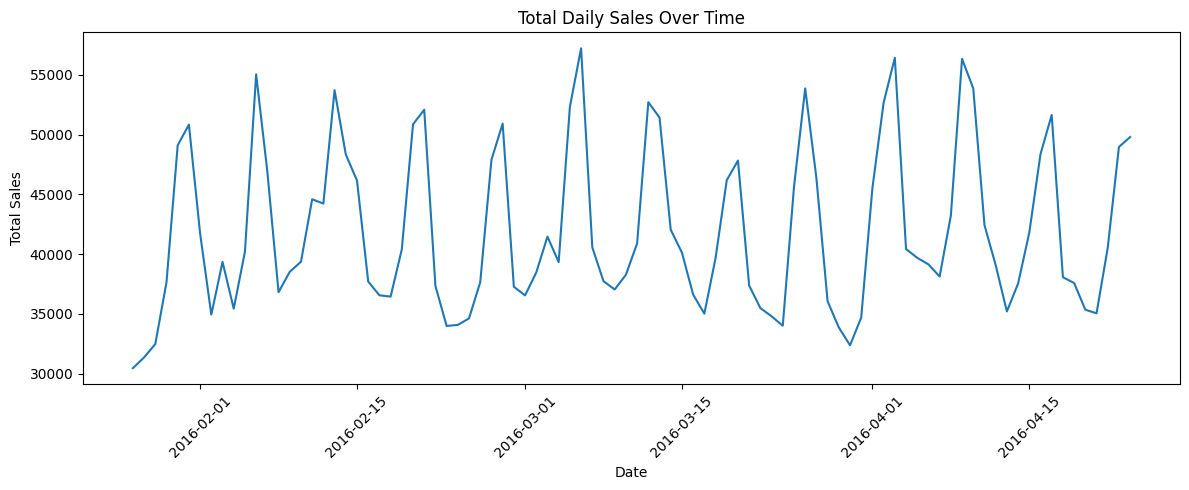

In [34]:
plt.figure(figsize=(12, 5))

plt.plot(daily_sales_df["date"], daily_sales_df["total_daily_sales"])

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Daily demand pattern

The aggregated daily sales series shows clear variation across days.

Key observations:

- Total demand fluctuates between roughly **30k and 57k units per day**
- The pattern appears **strongly cyclical**, suggesting weekly seasonality
- Peaks and troughs repeat consistently across the time window

This behaviour is typical for retail demand where:

- weekend demand patterns differ from weekdays
- promotional cycles or shopping habits influence daily sales

This confirms that time-based features (such as weekday or rolling demand statistics) will likely be important during feature engineering in the modeling phase.

## . Distribution and sparsity checks by item and store

In [35]:
store_sparsity_query = """
select
    store_id,
    count(*) as row_count,
    avg(sales) as avg_sales,
    sum(case when sales = 0 then 1 else 0 end) as zero_sales_rows,
    100.0 * sum(case when sales = 0 then 1 else 0 end) / count(*) as zero_sales_pct
from gold.gold_m5_daily_feature_mart
group by store_id
order by store_id
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(store_sparsity_query))
    store_sparsity_df = pd.DataFrame(result.fetchall(), columns=result.keys())

store_sparsity_df

,store_id,row_count,avg_sales,zero_sales_rows,zero_sales_pct
0,CA_1,274410,1,149989,54.658722349768594
1,CA_2,274410,1,146827,53.506431981341787
2,CA_3,274410,2,132133,48.151670857476039
3,CA_4,274410,0,174679,63.656207864144892
4,TX_1,274410,1,173808,63.338799606428337
5,TX_2,274410,1,158992,57.939579461389891
6,TX_3,274410,1,164141,59.815968805801537
7,WI_1,274410,1,151069,55.052294012608869
8,WI_2,274410,1,155942,56.828103932072446
9,WI_3,274410,1,167103,60.895375532961626


### Store-level sparsity summary

The store-level demand profile confirms that the dataset is highly sparse across all locations.

Key observations:

- Every store contains **274,410 rows**, confirming balanced coverage across locations.
- Average daily sales per item-store combination are generally **~1 unit or less**.
- The percentage of zero-demand days ranges roughly between **48% and 64%** depending on the store.

This confirms that sparse demand is a structural characteristic of the dataset rather than an anomaly in a particular location.

For modeling, this implies:

- baselines must handle many zero-demand observations
- error metrics should account for sparsity
- feature engineering should consider temporal aggregation or lag behavior

## 13. Correlation and initial signal review

In [36]:
numeric_sample_query = """
select
    sales,
    sell_price,
    temperature_2m_max,
    temperature_2m_min,
    precipitation_sum,
    wind_speed_10m_max,
    trends_walmart,
    trends_grocery_store,
    trends_discount_store,
    trends_cleaning_supplies
from gold.gold_m5_daily_feature_mart
limit 50000
"""

with warehouse_engine.begin() as conn:
    result = conn.execute(text(numeric_sample_query))
    corr_sample_df = pd.DataFrame(result.fetchall(), columns=result.keys())

corr_sample_df.head()

,sales,sell_price,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,trends_walmart,trends_grocery_store,trends_discount_store,trends_cleaning_supplies
0,1,6,16.3,6.7,15.0,10.1,54,50,73,74
1,0,3,25.0,10.2,0.0,13.6,54,52,65,57
2,0,1,28.6,11.8,0.0,6.5,56,54,62,76
3,0,4,28.6,11.8,0.0,6.5,56,54,62,76
4,1,4,19.5,5.9,0.0,11.2,54,57,61,78


In [37]:
corr_matrix = corr_sample_df.corr(numeric_only=True)

corr_matrix["sales"].sort_values(ascending=False)

sales                       1.000000
trends_grocery_store        0.043112
trends_walmart              0.042756
trends_discount_store       0.042510
precipitation_sum          -0.002621
temperature_2m_max         -0.008463
trends_cleaning_supplies   -0.010158
temperature_2m_min         -0.010555
wind_speed_10m_max         -0.030882
Name: sales, dtype: float64

### Initial correlation signals

The quick correlation check shows that individual external features have **very weak linear correlation with `sales`**.

This is expected for retail demand data because:

- demand is influenced by **many interacting factors**
- most predictive power comes from **temporal patterns and lagged demand**
- external features (weather, macro, trends) typically provide **contextual improvements rather than strong standalone signals**

This means the most important features for forecasting will likely be:

- lagged demand features
- rolling demand statistics
- calendar effects (weekday, seasonality)
- price dynamics

External features will still be useful, but mainly as **supporting signals** rather than primary drivers of the model.

## Leakage-risk review

### Leakage-risk review

At this stage, no obvious data leakage risks are visible from the current feature set.

The dataset contains:

Identifiers  
- `id`
- `item_id`
- `dept_id`
- `cat_id`
- `store_id`
- `state_id`

Time fields  
- `d`
- `date`
- `wm_yr_wk`

Target  
- `sales`

Commercial feature  
- `sell_price`

External features  
- weather indicators
- macroeconomic indicators
- Google Trends indicators

None of these fields directly contain **future information about sales**.

However, future leakage can occur later during feature engineering if lagged or rolling statistics are constructed incorrectly. Therefore, all future feature creation must strictly ensure that only **historical information available at prediction time** is used.

This notebook confirms that the **raw feature mart itself does not introduce leakage**, which makes it safe as the base dataset for modeling.

## EDA findings and modeling implications

### Key findings from EDA

The exploratory analysis of `gold.gold_m5_daily_feature_mart` confirms several important characteristics of the dataset:

**1. Dataset structure**
- Grain is correctly defined as **one row per `(store_id, item_id, date)`**
- No duplicate key rows were detected
- The dataset contains **2.7M rows**, making warehouse-side analysis appropriate

**2. Target characteristics**
- `sales` contains **no missing values**
- Sales are **non-negative**
- The dataset is **highly sparse**, with more than half of observations equal to zero

**3. Feature completeness**
- Most features contain **no missing values**
- `sell_price` contains missing values that will require handling during feature engineering

**4. Temporal behavior**
- Aggregated daily demand shows **clear cyclical patterns**, indicating temporal structure
- This suggests that **time-derived and lag features** will be important for forecasting

**5. External features**
- Weather, macroeconomic, and trends features are present
- Their direct correlation with sales is weak, which is typical for retail demand

### Modeling implications

Based on this analysis:

- Forecasting models will rely heavily on **lagged demand and time-based features**
- Sparse demand must be handled carefully during modeling
- External features will likely provide **incremental improvements rather than primary signal**
- Proper feature engineering will be critical to extract predictive power from the dataset

## Decisions to carry into the modeling notebook

### Decisions for the modeling phase

Based on the EDA results, the following decisions will guide the next notebook (model development):

**Dataset**
- Continue using `gold.gold_m5_daily_feature_mart` as the base modeling dataset.

**Forecast grain**
- Forecast at the **daily `(store_id, item_id)` level**.

**Target**
- Target variable remains **`sales`**.

**Key modeling considerations**
- Demand is **highly sparse**, with many zero-sales observations.
- Temporal structure is clearly present, suggesting strong value from:
  - lagged demand features
  - rolling demand statistics
  - calendar-based features.

**Feature engineering priorities**
Future modeling notebooks will create:

- lag features (e.g., previous day, previous week)
- rolling statistics (7-day, 14-day, 28-day windows)
- calendar features (weekday, week-of-year, etc.)
- price-related transformations
- indicators for price availability

**External signals**
Weather, macroeconomic, and Google Trends features will be retained as contextual predictors but are not expected to be primary drivers of the model.

These decisions establish the foundation for the next stage: **baseline model development and feature engineering.**

## Out of scope for this notebook

### Out of scope for this notebook

This notebook focuses only on **EDA and modeling readiness checks**.

The following tasks are intentionally **not performed here**:

- feature engineering (lags, rolling statistics, calendar features)
- dataset splitting for training/validation/testing
- baseline model construction
- machine learning model training
- experiment tracking with MLflow
- model packaging or registration
- batch inference pipeline development
- monitoring or retraining workflows

These tasks will be implemented in the **next notebooks and production training code**, once the dataset structure and quality have been validated.